In [290]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [291]:
data = pd.read_csv('Hyderabad.csv')

In [292]:
data.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,6968000,1340,Nizampet,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
1,29000000,3498,Hitech City,4,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,6590000,1318,Manikonda,2,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5739000,1295,Alwal,3,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,5679000,1145,Kukatpally,2,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0


In [293]:
data.shape

(2518, 40)

In [294]:
data.isnull().sum().sum()

np.int64(0)

In [295]:
data.describe()

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
count,2.518000e+03,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,...,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000,2518.000000
mean,9.818380e+06,1644.571088,2.623511,0.227562,0.412629,0.739873,0.709690,0.619142,0.559968,0.606434,...,0.975774,0.360207,0.607228,0.342732,0.330024,0.321287,0.334392,0.342335,0.341144,0.324861
std,8.777113e+06,746.256956,0.687330,0.419341,1.626445,1.611024,1.615231,1.624426,1.627686,1.625308,...,1.557725,1.622778,1.625256,1.621178,1.619894,1.618953,1.620347,1.621139,1.621023,1.619344
min,2.000000e+06,500.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.760000e+06,1160.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.754000e+06,1500.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.090000e+07,1829.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.650000e+08,9400.000000,8.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


In [296]:
data.columns

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator'],
      dtype='object')

In [297]:
data["Resale"].unique(), data["Resale"].value_counts()

(array([0, 1]),
 Resale
 0    1945
 1     573
 Name: count, dtype: int64)

In [298]:
data["No. of Bedrooms"].unique(), data["No. of Bedrooms"].value_counts()

(array([2, 4, 3, 1, 5, 8, 6]),
 No. of Bedrooms
 3    1207
 2    1090
 4     160
 1      37
 5      20
 8       2
 6       2
 Name: count, dtype: int64)

In [299]:
data["Children'splayarea"].unique(), data["Children'splayarea"].value_counts()

(array([1, 0, 9]),
 Children'splayarea
 0    1291
 1    1143
 9      84
 Name: count, dtype: int64)

In [300]:
OHE_cols =['Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator']


In [301]:
# OHE_cols_data = data[OHE_cols].copy()

In [302]:
# OHE_cols_data.shape

In [303]:
for column in OHE_cols:
    print(column, ":", data[column].unique())
    print(column, ":", data[column].value_counts())

Resale : [0 1]
Resale : Resale
0    1945
1     573
Name: count, dtype: int64
MaintenanceStaff : [0 1 9]
MaintenanceStaff : MaintenanceStaff
0    2151
1     283
9      84
Name: count, dtype: int64
Gymnasium : [1 0 9]
Gymnasium : Gymnasium
0    1327
1    1107
9      84
Name: count, dtype: int64
SwimmingPool : [1 0 9]
SwimmingPool : SwimmingPool
0    1403
1    1031
9      84
Name: count, dtype: int64
LandscapedGardens : [1 0 9]
LandscapedGardens : LandscapedGardens
0    1631
1     803
9      84
Name: count, dtype: int64
JoggingTrack : [1 0 9]
JoggingTrack : JoggingTrack
0    1780
1     654
9      84
Name: count, dtype: int64
RainWaterHarvesting : [1 0 9]
RainWaterHarvesting : RainWaterHarvesting
0    1663
1     771
9      84
Name: count, dtype: int64
IndoorGames : [1 0 9]
IndoorGames : IndoorGames
0    1728
1     706
9      84
Name: count, dtype: int64
ShoppingMall : [0 1 9]
ShoppingMall : ShoppingMall
0    2268
1     166
9      84
Name: count, dtype: int64
Intercom : [1 0 9]
Intercom : I

In [304]:
data.replace(9,np.nan, inplace=True)

In [305]:
data.isna().sum()

Price                   0
Area                    0
Location                0
No. of Bedrooms         0
Resale                  0
MaintenanceStaff       84
Gymnasium              84
SwimmingPool           84
LandscapedGardens      84
JoggingTrack           84
RainWaterHarvesting    84
IndoorGames            84
ShoppingMall           84
Intercom               84
SportsFacility         84
ATM                    84
ClubHouse              84
School                 84
24X7Security           84
PowerBackup            84
CarParking             84
StaffQuarter           84
Cafeteria              84
MultipurposeRoom       84
Hospital               84
WashingMachine         84
Gasconnection          84
AC                     84
Wifi                   84
Children'splayarea     84
LiftAvailable          84
BED                    84
VaastuCompliant        84
Microwave              84
GolfCourse             84
TV                     84
DiningTable            84
Sofa                   84
Wardrobe    

In [306]:
data.dropna(inplace=True)
data.isna().sum()

Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Refrigerator           0


In [307]:
data.describe()

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
count,2.434000e+03,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,...,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000
mean,9.844925e+06,1644.151602,2.626130,0.221446,0.116270,0.454807,0.423583,0.329910,0.268694,0.316763,...,0.698850,0.062038,0.317584,0.043961,0.030813,0.021775,0.035333,0.043550,0.042317,0.025472
std,8.852947e+06,748.134812,0.685046,0.415305,0.320614,0.498056,0.494227,0.470277,0.443371,0.465310,...,0.458852,0.241274,0.465632,0.205050,0.172848,0.145978,0.184657,0.204133,0.201353,0.157588
min,2.000000e+06,500.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.760000e+06,1165.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.800000e+06,1500.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.090000e+07,1820.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.650000e+08,9400.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [308]:
data["Wifi"].unique(), data["Wifi"].value_counts()

(array([0., 1.]),
 Wifi
 0.0    2369
 1.0      65
 Name: count, dtype: int64)

In [309]:
data["Wardrobe"].unique(), data["Wardrobe"].value_counts()

(array([0., 1.]),
 Wardrobe
 0.0    2331
 1.0     103
 Name: count, dtype: int64)

In [310]:
for column in OHE_cols:
    print(column, ":", data[column].unique())
    print(column, ":", data[column].value_counts())

Resale : [0 1]
Resale : Resale
0    1895
1     539
Name: count, dtype: int64
MaintenanceStaff : [0. 1.]
MaintenanceStaff : MaintenanceStaff
0.0    2151
1.0     283
Name: count, dtype: int64
Gymnasium : [1. 0.]
Gymnasium : Gymnasium
0.0    1327
1.0    1107
Name: count, dtype: int64
SwimmingPool : [1. 0.]
SwimmingPool : SwimmingPool
0.0    1403
1.0    1031
Name: count, dtype: int64
LandscapedGardens : [1. 0.]
LandscapedGardens : LandscapedGardens
0.0    1631
1.0     803
Name: count, dtype: int64
JoggingTrack : [1. 0.]
JoggingTrack : JoggingTrack
0.0    1780
1.0     654
Name: count, dtype: int64
RainWaterHarvesting : [1. 0.]
RainWaterHarvesting : RainWaterHarvesting
0.0    1663
1.0     771
Name: count, dtype: int64
IndoorGames : [1. 0.]
IndoorGames : IndoorGames
0.0    1728
1.0     706
Name: count, dtype: int64
ShoppingMall : [0. 1.]
ShoppingMall : ShoppingMall
0.0    2268
1.0     166
Name: count, dtype: int64
Intercom : [1. 0.]
Intercom : Intercom
0.0    1480
1.0     954
Name: count, dty

#### Now, it is time to identify what columns are strongly correlated to 'Price'

### Co-relation Analaysis

In [311]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2434 entries, 0 to 2433
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Price                2434 non-null   int64  
 1   Area                 2434 non-null   int64  
 2   Location             2434 non-null   object 
 3   No. of Bedrooms      2434 non-null   int64  
 4   Resale               2434 non-null   int64  
 5   MaintenanceStaff     2434 non-null   float64
 6   Gymnasium            2434 non-null   float64
 7   SwimmingPool         2434 non-null   float64
 8   LandscapedGardens    2434 non-null   float64
 9   JoggingTrack         2434 non-null   float64
 10  RainWaterHarvesting  2434 non-null   float64
 11  IndoorGames          2434 non-null   float64
 12  ShoppingMall         2434 non-null   float64
 13  Intercom             2434 non-null   float64
 14  SportsFacility       2434 non-null   float64
 15  ATM                  2434 non-null   float6

In [312]:
number_cols = data.select_dtypes(include=['int64', 'float64']).columns

In [313]:
print(type(number_cols))

<class 'pandas.core.indexes.base.Index'>


In [314]:
data[number_cols].shape

(2434, 39)

In [315]:
corr_matrix = data[number_cols].corr().round(2)
corr_matrix

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
Price,1.00,0.85,0.63,0.21,0.15,0.28,0.31,0.27,0.31,0.24,...,0.16,0.09,0.23,0.02,-0.04,0.12,0.09,0.07,0.08,0.11
Area,0.85,1.00,0.79,0.18,0.21,0.30,0.32,0.28,0.34,0.28,...,0.17,0.06,0.28,-0.00,-0.03,0.10,0.07,0.06,0.07,0.10
No. of Bedrooms,0.63,0.79,1.00,0.14,0.19,0.25,0.28,0.25,0.30,0.23,...,0.17,0.05,0.30,-0.03,-0.04,0.10,0.07,0.03,0.06,0.08
Resale,0.21,0.18,0.14,1.00,0.03,-0.08,-0.07,-0.01,-0.02,-0.04,...,0.01,0.25,-0.06,0.07,-0.05,0.20,0.22,0.25,0.29,0.19
MaintenanceStaff,0.15,0.21,0.19,0.03,1.00,0.31,0.32,0.43,0.43,0.41,...,0.21,0.02,0.42,-0.02,0.28,-0.00,0.00,-0.00,0.05,0.02
Gymnasium,0.28,0.30,0.25,-0.08,0.31,1.00,0.89,0.70,0.65,0.58,...,0.52,-0.04,0.51,-0.00,0.20,0.07,0.12,0.10,0.04,0.09
SwimmingPool,0.31,0.32,0.28,-0.07,0.32,0.89,1.00,0.73,0.69,0.62,...,0.50,-0.03,0.53,0.00,0.21,0.06,0.11,0.08,0.02,0.08
LandscapedGardens,0.27,0.28,0.25,-0.01,0.43,0.70,0.73,1.00,0.75,0.68,...,0.43,0.03,0.61,0.02,0.25,0.04,0.11,0.12,0.13,0.10
JoggingTrack,0.31,0.34,0.30,-0.02,0.43,0.65,0.69,0.75,1.00,0.69,...,0.38,-0.05,0.66,0.01,0.28,0.07,0.05,0.03,0.00,0.08
RainWaterHarvesting,0.24,0.28,0.23,-0.04,0.41,0.58,0.62,0.68,0.69,1.00,...,0.42,-0.06,0.71,-0.03,0.26,0.05,0.03,0.01,0.01,0.05


<Axes: >

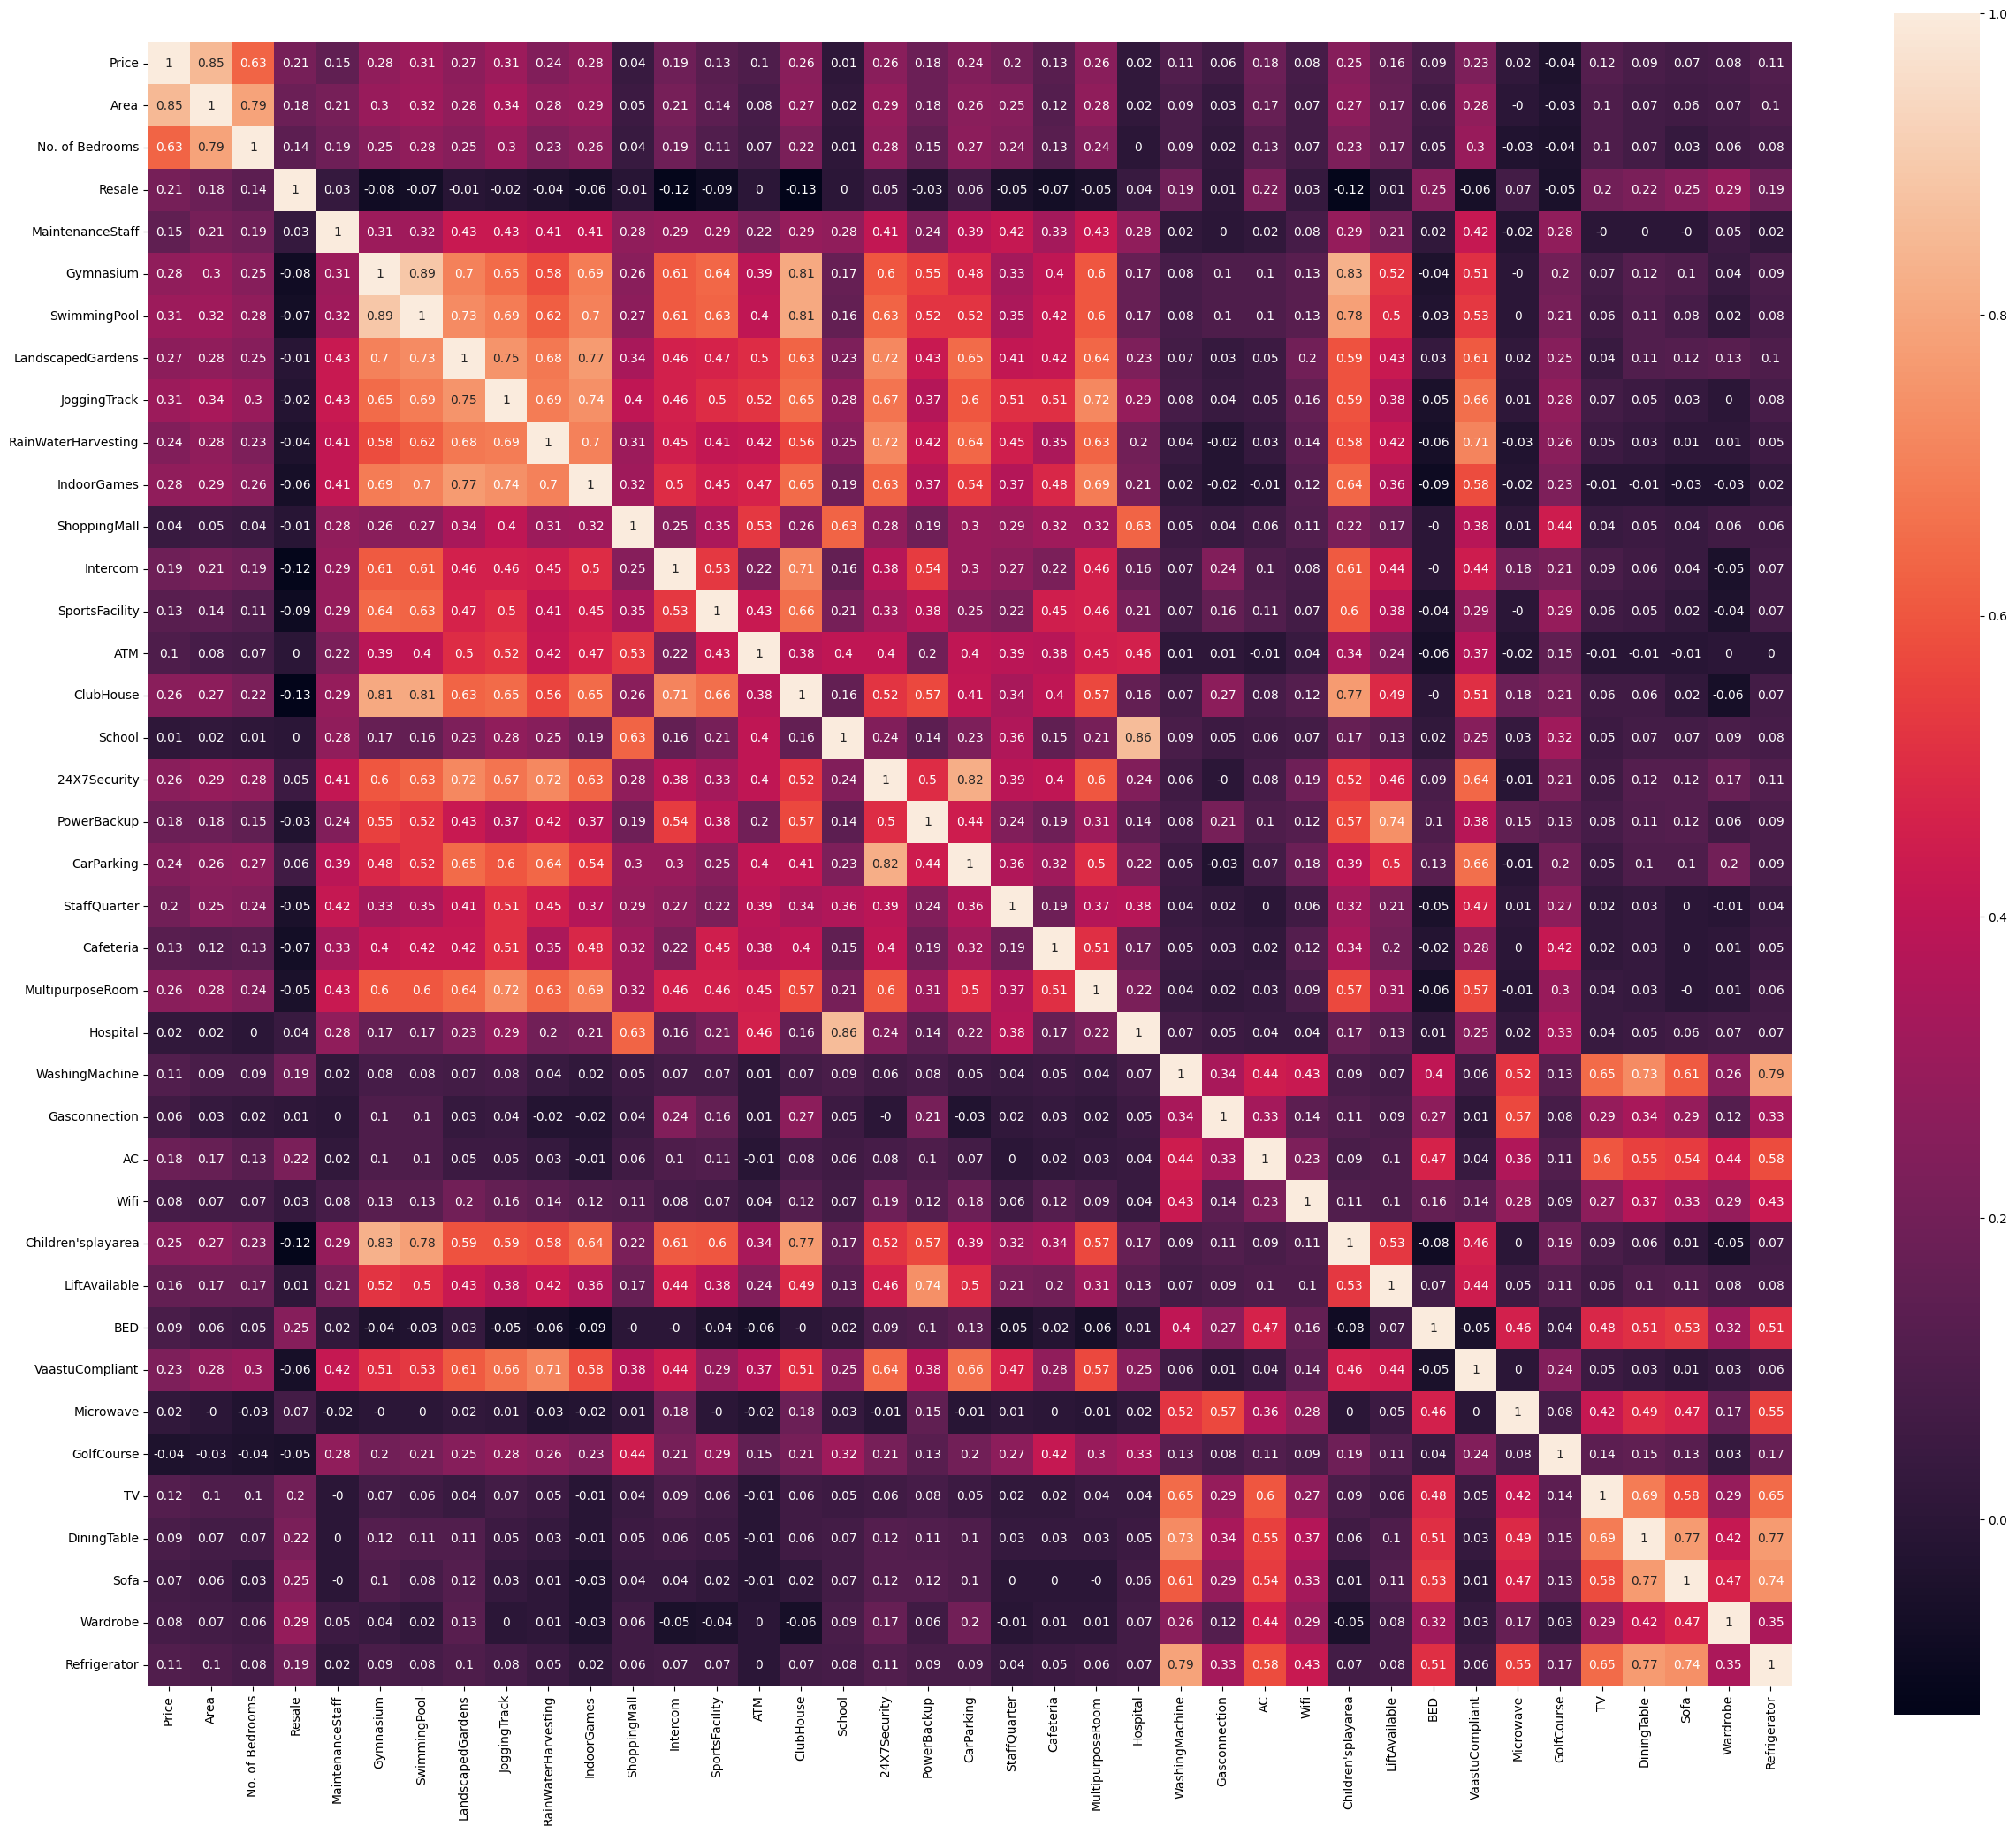

In [316]:

plt.figure(figsize=(30,25))
sns.heatmap(corr_matrix, annot=True, square=True)

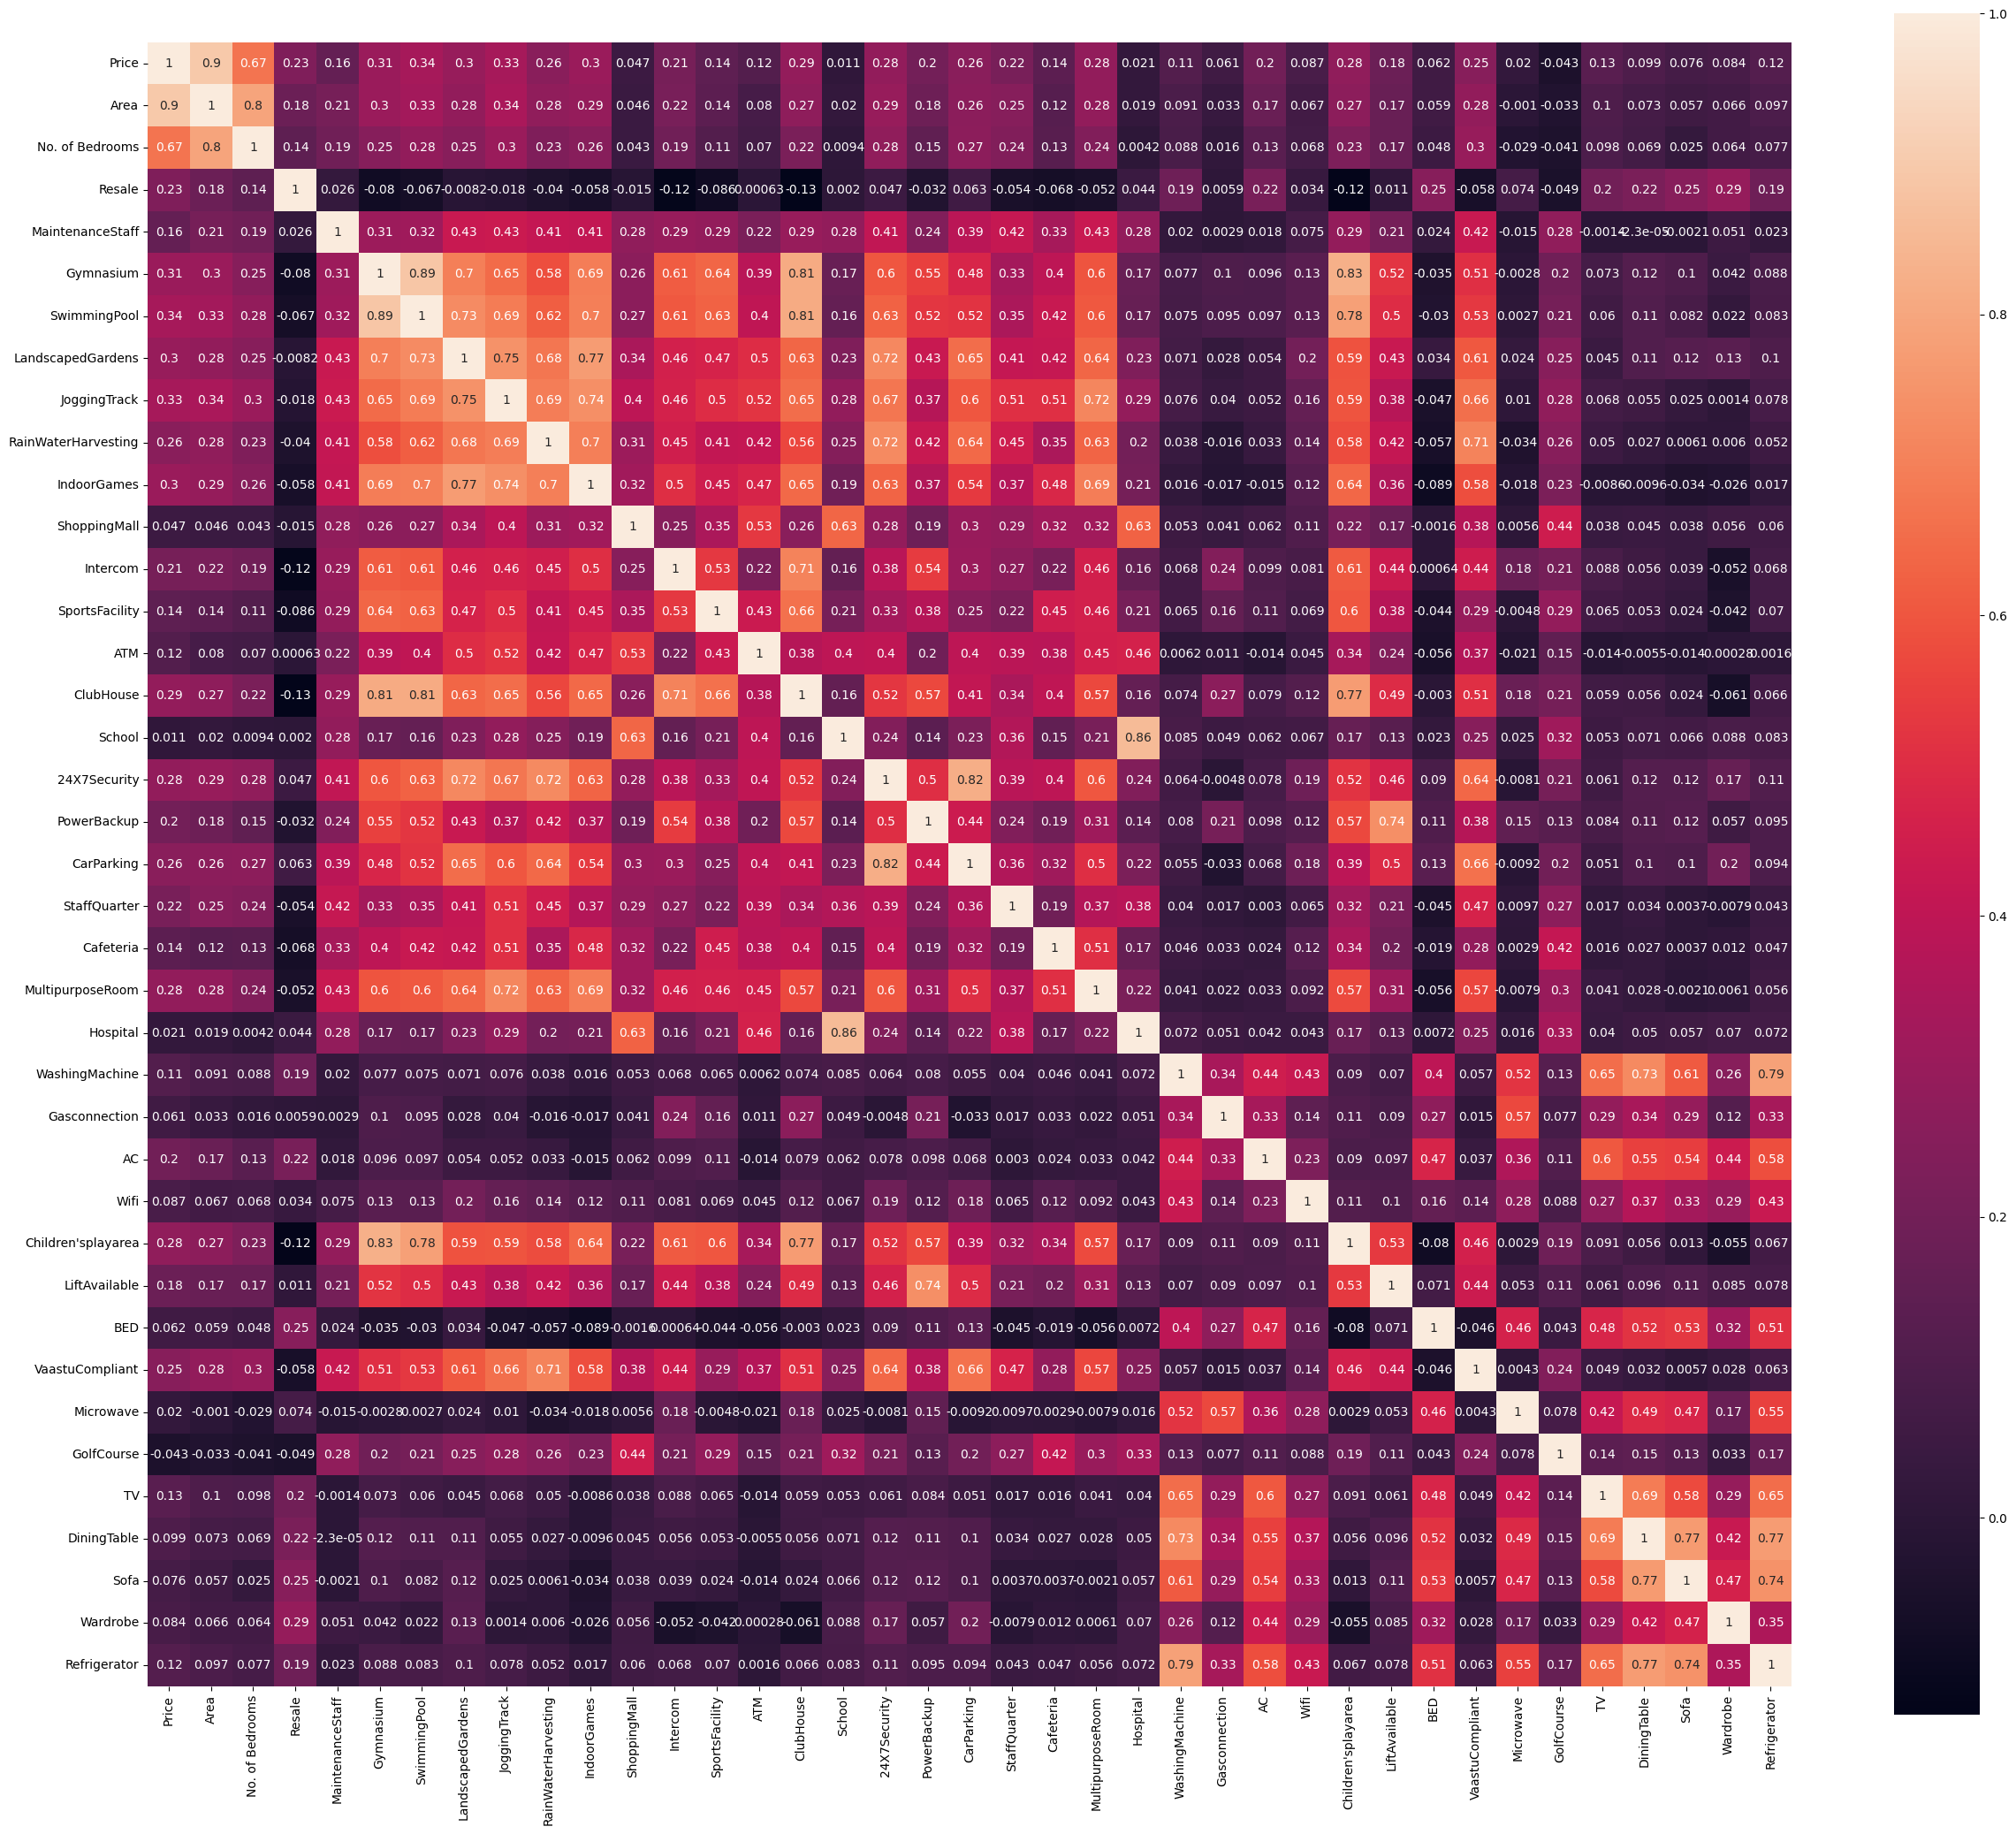

Top 10 Features Correlated with Price
----------------------------------------
Area                 0.896673
No. of Bedrooms      0.671148
SwimmingPool         0.335107
JoggingTrack         0.333075
Gymnasium            0.306215
IndoorGames          0.303918
LandscapedGardens    0.296435
ClubHouse            0.286476
MultipurposeRoom     0.282694
24X7Security         0.282173
Name: Price, dtype: float64


In [336]:
# Create correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(30,25))
sns.heatmap(corr_matrix, annot=True, square=True)
plt.show()

# Top 10 features correlated with Price
top_corr = (
    corr_matrix['Price']
    .drop('Price')          # Remove self-correlation (Price=1.0)
    .abs()                  # Use absolute correlation values
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Features Correlated with Price")
print("-" * 40)
print(top_corr)

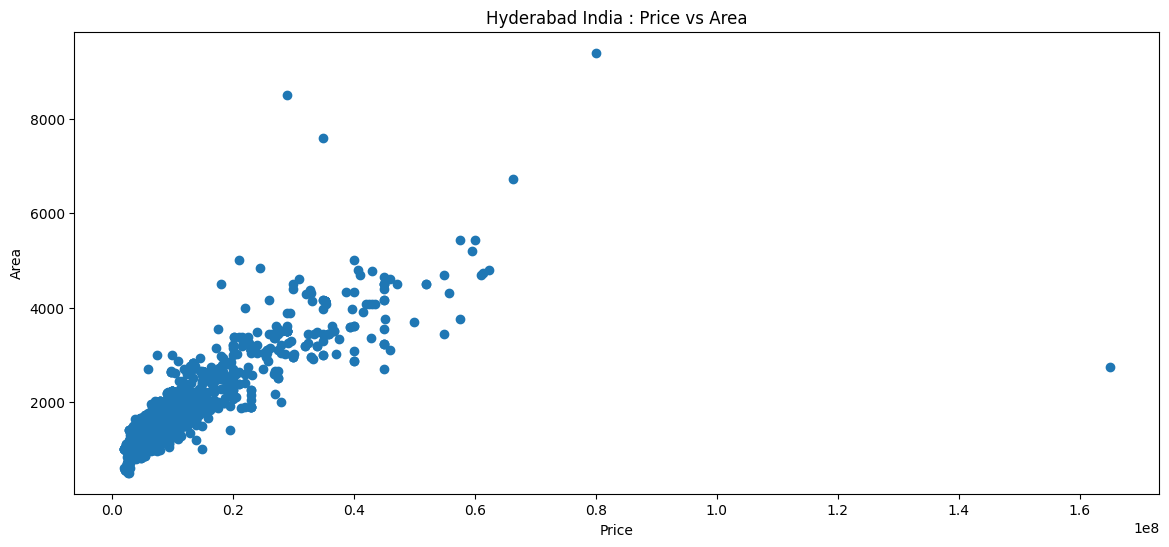

In [317]:
plt.figure(figsize=(14,6))
plt.scatter(x = data['Price'], y=data['Area'])
plt.xlabel('Price')
plt.ylabel('Area')
plt.title('Hyderabad India : Price vs Area');


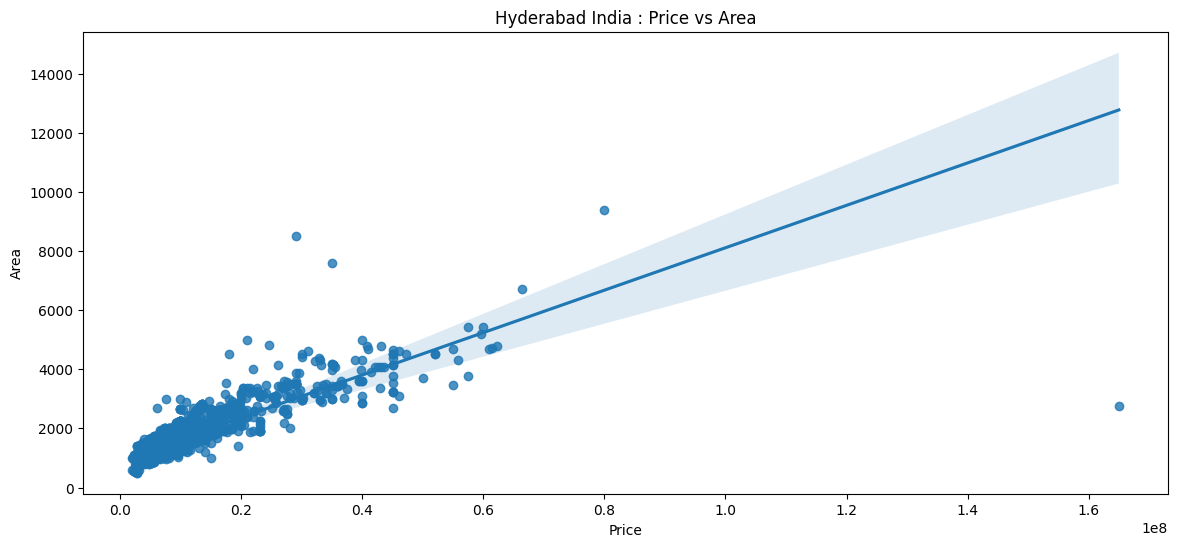

In [318]:
plt.figure(figsize=(14,6))
sns.regplot(x = data['Price'], y=data['Area'])
plt.xlabel('Price')
plt.ylabel('Area')
plt.title('Hyderabad India : Price vs Area');

In [319]:
normal_house_range = data["Price"]< 100000000
normal_house_range.value_counts()

Price
True     2433
False       1
Name: count, dtype: int64

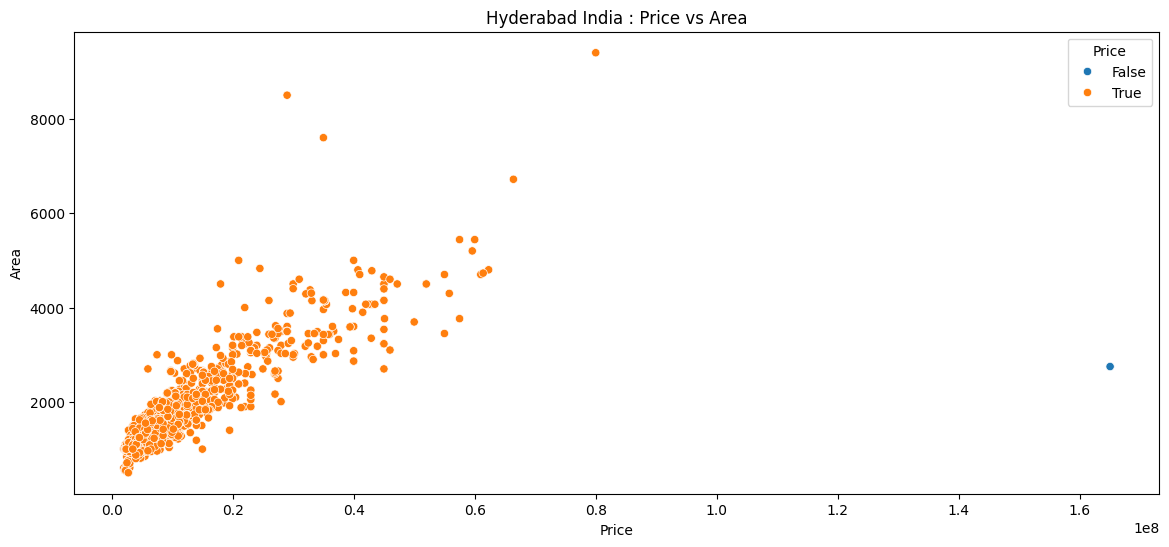

In [320]:
# Trying to separate the values using a scatterplot with 'color attribute'
plt.figure(figsize=(14,6))
sns.scatterplot(x = data['Price'], y=data['Area'], hue=normal_house_range)
plt.xlabel('Price')
plt.ylabel('Area')
plt.title('Hyderabad India : Price vs Area');


In [321]:
print(data.shape)
print(data['Price'].max())

(2434, 40)
165000000


In [322]:
data = data[data['Price'] <= 100000000]

In [323]:
print(data.shape)
print(data['Price'].max())

(2433, 40)
80000000


/var/folders/0d/zzcr1q6j13j_nz7xs4mpykgr0000gn/T/ipykernel_10498/2246210657.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hyd_houses = data[normal_house_range]


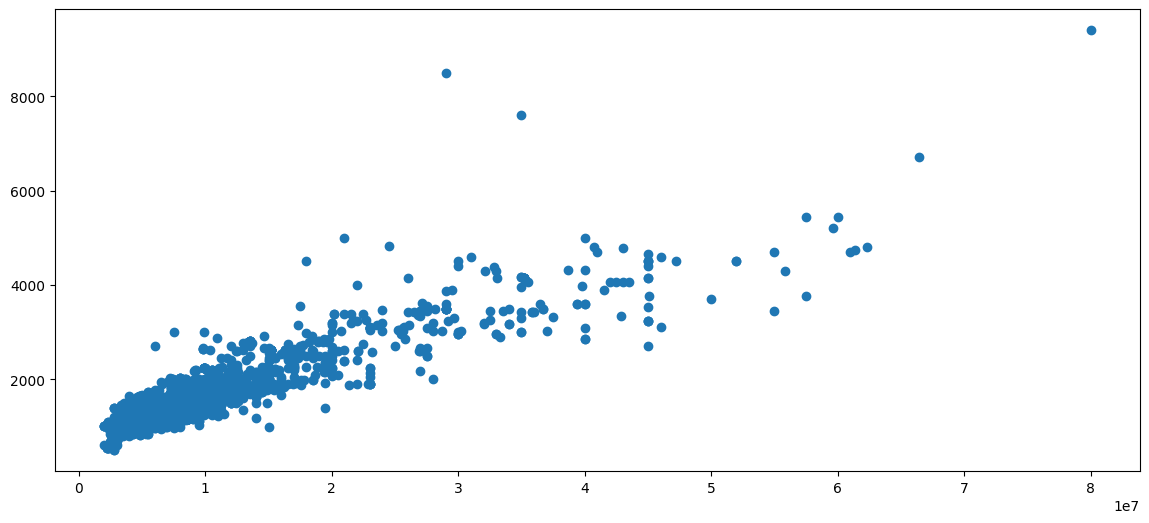

In [324]:
# Removing the expensive houses
plt.figure(figsize=(14,6))
hyd_houses = data[normal_house_range]
plt.scatter(x = data['Price'], y=data['Area']);

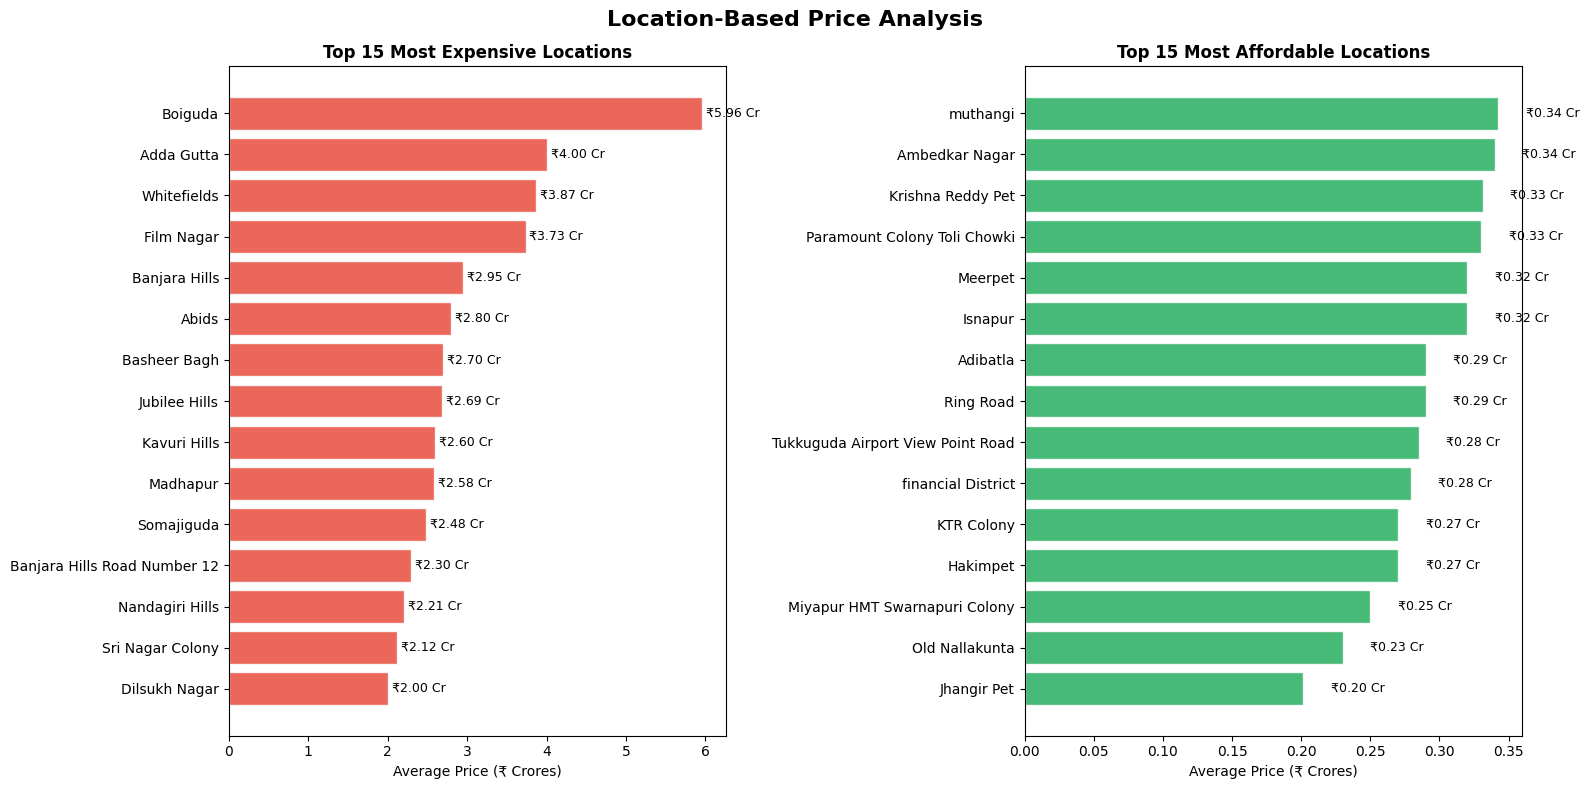

✅ Saved → outputs/location_analysis_crores.png


In [ ]:
# Average price by location
loc_avg = data.groupby('Location')['Price'].mean().sort_values(ascending=False)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Location-Based Price Analysis', fontsize=16, fontweight='bold')

# =========================
# Top 15 Expensive Locations
# =========================
top15 = loc_avg.head(15)

axes[0].barh(
    top15.index[::-1],
    top15.values[::-1] / 1e7,   # Convert to Crores
    color="#F61C04",
    alpha=0.85,
    edgecolor='white'
)

axes[0].set_title('Top 15 Most Expensive Locations', fontweight='bold')
axes[0].set_xlabel('Average Price (₹ Crores)')

# Add value labels
for i, (loc, val) in enumerate(zip(top15.index[::-1], top15.values[::-1])):
    axes[0].text(
        val/1e7 + 0.05,
        i,
        f'₹{val/1e7:.2f} Cr',
        va='center',
        fontsize=9
    )

# ==========================
# Top 15 Affordable Locations
# ==========================
bot15 = loc_avg.tail(15)

axes[1].barh(
    bot15.index[::-1],
    bot15.values[::-1] / 1e7,   # Convert to Crores
    color="#06F76B",
    alpha=0.85,
    edgecolor='white'
)

axes[1].set_title('Top 15 Most Affordable Locations', fontweight='bold')
axes[1].set_xlabel('Average Price (₹ Crores)')

# Add value labels
for i, (loc, val) in enumerate(zip(bot15.index[::-1], bot15.values[::-1])):
    axes[1].text(
        val/1e7 + 0.02,
        i,
        f'₹{val/1e7:.2f} Cr',
        va='center',
        fontsize=9
    )

# Improve layout
plt.tight_layout()

# Save figure
plt.savefig(
    'location_analysis.png',
    bbox_inches='tight',
    dpi=150
)

# Show plot
plt.show()

print("✅ Saved → location_analysis.png")

In [325]:
cleaned_data= data.to_csv('Hyderabad_houses_cleaned_DS.csv', index=False)

In [365]:
selected_columns = [
    "Area",
    "Location",
    "No. of Bedrooms",
    "Resale",
    "CarParking",
    "SwimmingPool",
    "JoggingTrack",
    "LiftAvailable",
    "Price"
]

df = data[selected_columns]

df.head()

,Area,Location,No. of Bedrooms,Resale,CarParking,SwimmingPool,JoggingTrack,LiftAvailable,Price
0,1340,Nizampet,2,0,1.0,1.0,1.0,1.0,6968000
1,3498,Hitech City,4,0,1.0,1.0,1.0,1.0,29000000
2,1318,Manikonda,2,0,0.0,0.0,0.0,0.0,6590000
3,1295,Alwal,3,1,0.0,0.0,0.0,1.0,5739000
4,1145,Kukatpally,2,0,1.0,0.0,0.0,1.0,5679000


In [366]:
df = pd.get_dummies(
    df,
    columns=["Location"],
    drop_first=True
)

In [367]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [368]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [370]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R²:", lr_r2)

Linear Regression R²: 0.8396025981701427


In [371]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R²:", ridge_r2)

Ridge R²: 0.8433572076891207


In [372]:
from sklearn.model_selection import GridSearchCV
ridge = Ridge()

ridge_params = {
    'alpha': [0.001,0.01,0.1,1,10,50,100,500]
}

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Ridge R²:", round(ridge_r2,4))


Best Ridge Alpha: {'alpha': 10}
Ridge R²: 0.8464


In [373]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R²:", lasso_r2)

Lasso R²: 0.8425844734459886


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.109e+15, tolerance: 1.323e+13
  model = cd_fast.enet_coordinate_descent(


In [374]:
from sklearn.model_selection import GridSearchCV
lasso = Lasso(max_iter=10000)

lasso_params = {
    'alpha': [0.0001,0.001,0.01,0.1,1,10,50]
}

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Best Lasso Alpha:", lasso_grid.best_params_)
print("Lasso R²:", round(lasso_r2,4))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.361e+15, tolerance: 1.078e+13
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.565e+15, tolerance: 1.078e+13
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Best Lasso Alpha: {'alpha': 50}
Lasso R²: 0.8424


In [375]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "R2 Score":[
        lr_r2,
        ridge_r2,
        lasso_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results

,Model,R2 Score
1,Ridge,0.846350
2,Lasso,0.842433
0,Linear Regression,0.839603


In [376]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import r2_score

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [377]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R² =", round(rf_r2,4))

Random Forest R² = 0.9187


In [378]:
et = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

et_r2 = r2_score(y_test, et_pred)

print("Extra Trees R² =", round(et_r2,4))

Extra Trees R² = 0.9084


In [379]:
ada = AdaBoostRegressor(
    n_estimators=200,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

ada_r2 = r2_score(y_test, ada_pred)

print("AdaBoost R² =", round(ada_r2,4))

AdaBoost R² = 0.7829


In [380]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting R² =", round(gb_r2,4))

Gradient Boosting R² = 0.9114


In [381]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost R² =", round(xgb_r2,4))

NameError: name 'XGBRegressor' is not defined

In [382]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)

cat_r2 = r2_score(y_test, cat_pred)

print("CatBoost R² =", round(cat_r2,4))

NameError: name 'CatBoostRegressor' is not defined

In [383]:
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

lgbm_r2 = r2_score(y_test, lgbm_pred)

print("LightGBM R² =", round(lgbm_r2,4))

NameError: name 'LGBMRegressor' is not defined

In [384]:
ensemble_results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Extra Trees",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "CatBoost",
        "LightGBM"
    ],

    "R2 Score":[
        rf_r2,
        et_r2,
        ada_r2,
        gb_r2,
        xgb_r2,
        cat_r2,
        lgbm_r2
    ]
})

ensemble_results = ensemble_results.sort_values(
    by="R2 Score",
    ascending=False
)

ensemble_results.reset_index(drop=True,inplace=True)

ensemble_results

NameError: name 'xgb_r2' is not defined

In [385]:
best_model_name = ensemble_results.iloc[0]["Model"]

best_score = ensemble_results.iloc[0]["R2 Score"]

print("Best Model :", best_model_name)
print("Best R² :", round(best_score,4))

NameError: name 'ensemble_results' is not defined